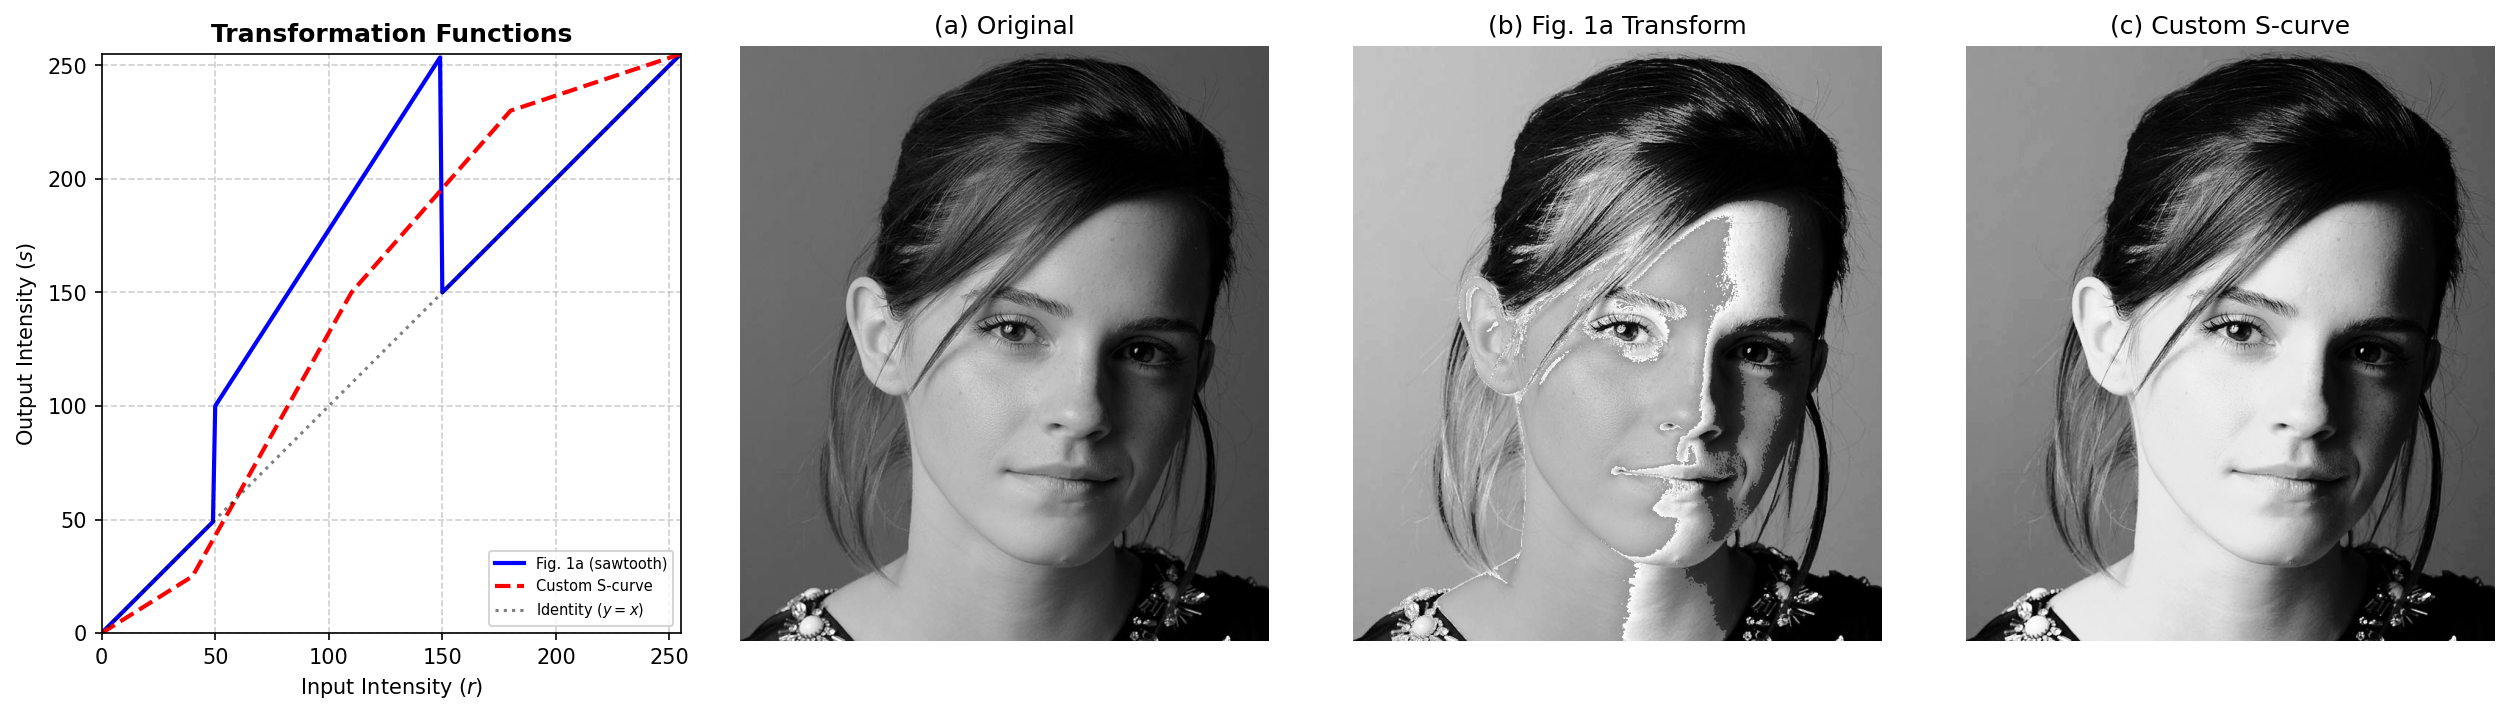

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
  
    bp = np.array(breakpoints, dtype=np.float32)
    lut = np.zeros(256, dtype=np.float32)

    for i in range(len(bp) - 1):
        x0, y0 = bp[i]
        x1, y1 = bp[i + 1]
        xs = np.arange(int(x0), int(x1) + 1)
        if x1 == x0:
            lut[xs] = y1
        else:
            lut[xs] = y0 + (y1 - y0) * (xs - x0) / (x1 - x0)

    lut = np.clip(np.round(lut), 0, 255).astype(np.uint8)
    return cv2.LUT(im, lut)


def build_lut(breakpoints):
    bp = np.array(breakpoints, dtype=np.float32)
    lut = np.zeros(256, dtype=np.float32)
    for i in range(len(bp) - 1):
        x0, y0 = bp[i]
        x1, y1 = bp[i + 1]
        xs = np.arange(int(x0), int(x1) + 1)
        if x1 == x0:
            lut[xs] = y1
        else:
            lut[xs] = y0 + (y1 - y0) * (xs - x0) / (x1 - x0)
    return lut



img_path = r'images\emma.jpeg'
im_orig = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

bp_default = [
    [0,   0],
    [50,  50],
    [50,  100],   # jump up
    [150, 255],
    [150, 150],   # jump down
    [255, 255]
]

# ---- (2) Custom smooth S-curve — no discontinuities, gentler contrast boost ----
bp_custom = [
    [0,   0],
    [40,  25],
    [110, 150],
    [180, 230],
    [255, 255]
]

im_trans_default = intensity_transform(im_orig, bp_default)
im_trans_custom  = intensity_transform(im_orig, bp_custom)

lut_def = build_lut(bp_default)
lut_cus = build_lut(bp_custom)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.5), dpi=150)

r = np.arange(256)
axes[0].plot(r, lut_def, 'b-', linewidth=2, label='Fig. 1a (sawtooth)')
axes[0].plot(r, lut_cus, 'r--', linewidth=2, label='Custom S-curve')
axes[0].plot([0, 255], [0, 255], 'k:', alpha=0.5, label='Identity ($y=x$)')
axes[0].set_title('Transformation Functions', fontweight='bold')
axes[0].set_xlabel('Input Intensity ($r$)')
axes[0].set_ylabel('Output Intensity ($s$)')
axes[0].set_xlim(0, 255); axes[0].set_ylim(0, 255)
axes[0].set_aspect('equal')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='lower right', fontsize=7)

axes[1].imshow(im_orig, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('(a) Original')
axes[1].axis('off')

axes[2].imshow(im_trans_default, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('(b) Fig. 1a Transform')
axes[2].axis('off')

axes[3].imshow(im_trans_custom, cmap='gray', vmin=0, vmax=255)
axes[3].set_title('(c) Custom S-curve')
axes[3].axis('off')

plt.tight_layout()
plt.show()

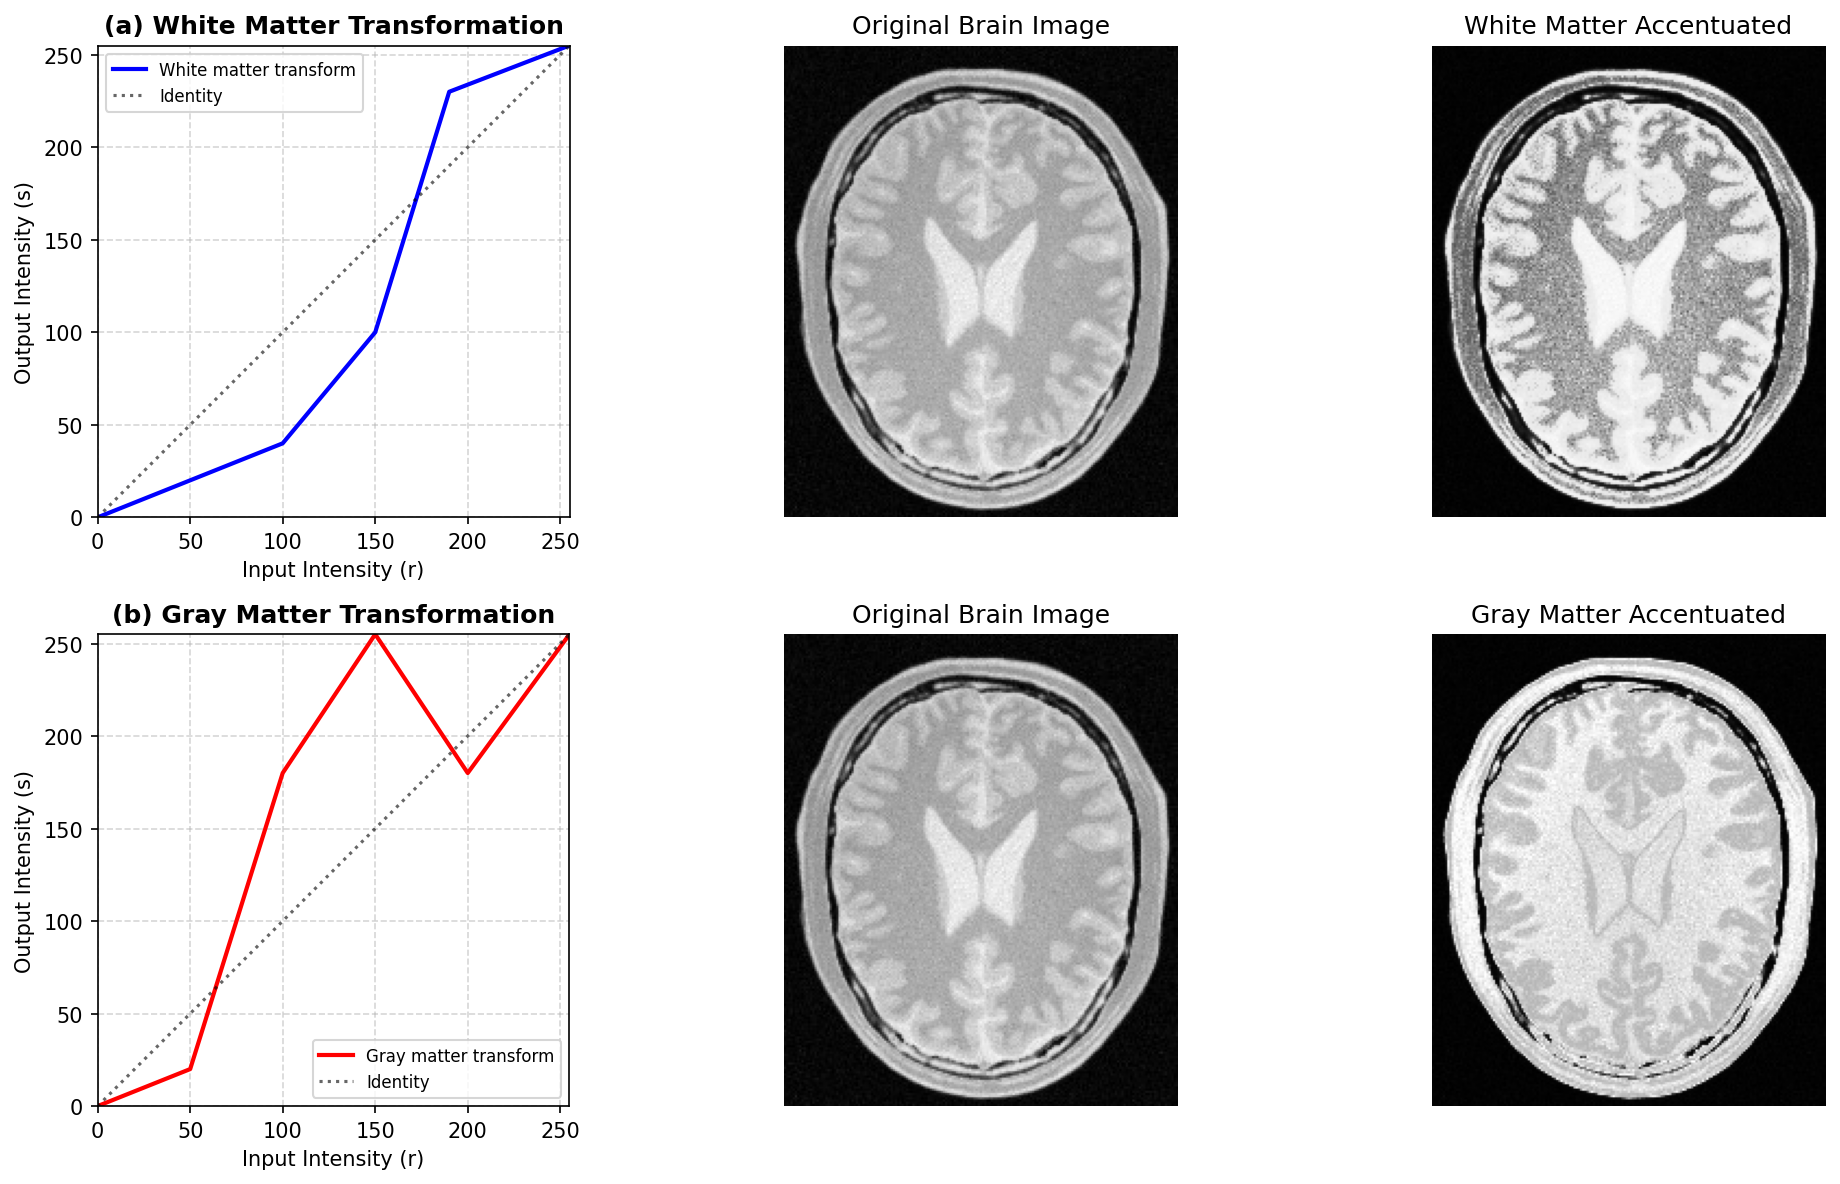

In [3]:
img_path = r'images\brain.jpeg'

im_orig = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if im_orig is None:
    raise FileNotFoundError("Could not find the image.")

# (a) ACCENTUATE WHITE MATTER
bp_white = [
    [0,   0],
    [100, 40],
    [150, 100],
    [190, 230],
    [255, 255]
]

# (b) ACCENTUATE GRAY MATTER
bp_gray = [
    [0,   0],
    [50,  20],
    [100, 180],
    [150, 255],
    [200, 180],
    [255, 255]
]

im_white = intensity_transform(im_orig, bp_white)
im_gray = intensity_transform(im_orig, bp_gray)

lut_white = build_lut(bp_white)
lut_gray = build_lut(bp_gray)

r = np.arange(256)
fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=150)

# WHITE MATTER
axes[0, 0].plot(
    r, lut_white,
    'b-', linewidth=2,
    label='White matter transform'
)

axes[0, 0].plot(
    [0, 255], [0, 255],
    'k:', alpha=0.6,
    label='Identity'
)

axes[0, 0].set_title(
    '(a) White Matter Transformation',
    fontweight='bold'
)

axes[0, 0].set_xlabel('Input Intensity (r)')
axes[0, 0].set_ylabel('Output Intensity (s)')
axes[0, 0].set_xlim(0, 255)
axes[0, 0].set_ylim(0, 255)
axes[0, 0].set_aspect('equal')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)
axes[0, 0].legend(fontsize=8)


axes[0, 1].imshow(
    im_orig,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[0, 1].set_title('Original Brain Image')
axes[0, 1].axis('off')


axes[0, 2].imshow(
    im_white,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[0, 2].set_title('White Matter Accentuated')
axes[0, 2].axis('off')

# GRAY MATTER
axes[1, 0].plot(
    r, lut_gray,
    'r-', linewidth=2,
    label='Gray matter transform'
)

axes[1, 0].plot(
    [0, 255], [0, 255],
    'k:', alpha=0.6,
    label='Identity'
)

axes[1, 0].set_title(
    '(b) Gray Matter Transformation',
    fontweight='bold'
)

axes[1, 0].set_xlabel('Input Intensity (r)')
axes[1, 0].set_ylabel('Output Intensity (s)')
axes[1, 0].set_xlim(0, 255)
axes[1, 0].set_ylim(0, 255)
axes[1, 0].set_aspect('equal')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)
axes[1, 0].legend(fontsize=8)


axes[1, 1].imshow(
    im_orig,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[1, 1].set_title('Original Brain Image')
axes[1, 1].axis('off')


axes[1, 2].imshow(
    im_gray,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[1, 2].set_title('Gray Matter Accentuated')
axes[1, 2].axis('off')


plt.tight_layout()
plt.show()